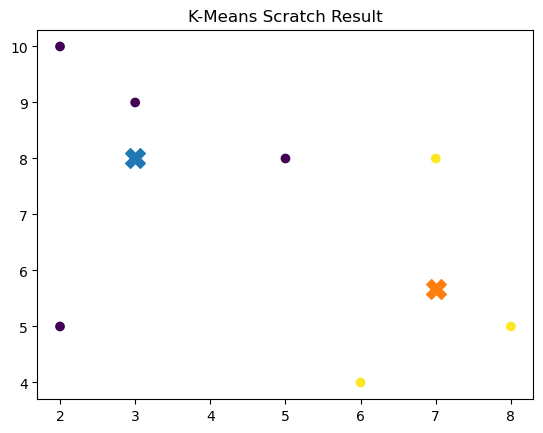

In [1]:
# Perform K-Means over given data using mathematical stepwise approach( Scratch) 
#Datapoints: (2,10), (2,5), (8,5), ( 3,9), (6,4), (5,8) ,(7,8)  

import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([(2,10),(2,5),(8,5),(3,9),(6,4),(5,8),(7,8)])

# Initial centroids
C1 = np.array([2,10])
C2 = np.array([8,5])

def euclidean(a,b):
    return np.sqrt(np.sum((a-b)**2))

def assign_clusters(X, C1, C2):
    clusters = []
    for point in X:
        d1 = euclidean(point, C1)
        d2 = euclidean(point, C2)
        clusters.append(0 if d1 < d2 else 1)
    return np.array(clusters)

def update_centroids(X, clusters):
    C1 = np.mean(X[clusters==0], axis=0)
    C2 = np.mean(X[clusters==1], axis=0)
    return C1, C2

# Iteration 1
clusters = assign_clusters(X, C1, C2)
C1, C2 = update_centroids(X, clusters)

# Iteration 2
clusters = assign_clusters(X, C1, C2)
C1, C2 = update_centroids(X, clusters)

# Plot
plt.scatter(X[:,0], X[:,1], c=clusters)
plt.scatter(C1[0], C1[1], marker='X', s=200)
plt.scatter(C2[0], C2[1], marker='X', s=200)
plt.title("K-Means Scratch Result")
plt.show()

c:\Users\22anj\anaconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\22anj\anaconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\22anj\anaconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\22anj\anaconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

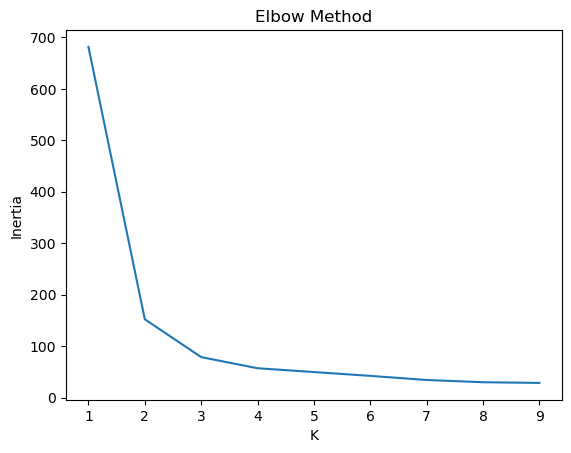

c:\Users\22anj\anaconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\22anj\anaconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\22anj\anaconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\22anj\anaconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

K= 2 Score= 0.6810461692117462
K= 3 Score= 0.5511916046195919
K= 4 Score= 0.49805050499728737
K= 5 Score= 0.4887488870931056


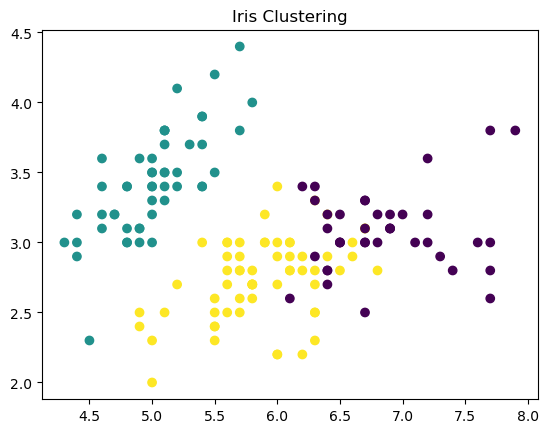

In [2]:
#Q.2 Using Iris dataset: Apply K-Means clustering, Use Elbow Method to determine  optimal K, Plot clusters, Compute silhouette score for different K, Plot score vs K 

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

data = load_iris()
X = data.data

# Elbow Method
inertia = []
for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia)
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

# Silhouette Score
for k in range(2,6):
    km = KMeans(n_clusters=k)
    labels = km.fit_predict(X)
    print("K=",k,"Score=",silhouette_score(X, labels))

# Final clustering
km = KMeans(n_clusters=3)
labels = km.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Iris Clustering")
plt.show()

In [5]:
#Q.3 For Vectors: A(1,4,8) and B(9,4,3) compute Euclidean distance, Manhattan distance, 
#Minkowski distance (p = 3), Cosine similarity

import numpy as np
from scipy.spatial.distance import hamming, jaccard

A = np.array([1,4,8])
B = np.array([9,4,3])

# Euclidean
print("Euclidean:", np.linalg.norm(A-B))

# Manhattan
print("Manhattan:", np.sum(np.abs(A-B)))

# Minkowski p=3
print("Minkowski:", np.power(np.sum(np.abs(A-B)**3),1/3))

# Cosine
cosine = np.dot(A,B)/(np.linalg.norm(A)*np.linalg.norm(B))
print("Cosine:", cosine)

# Hamming
print("Hamming:", hamming([1,0,1,1,1,0,1],[1,0,0,1,0,0,1])*7)

# Jaccard
print("Jaccard Distance:", jaccard([1,1,0,0,1],[1,0,0,1,1]))

def edit_distance_matrix(s1, s2):
    m, n = len(s1), len(s2)
    
    # Create matrix
    dp = [[0]*(n+1) for _ in range(m+1)]
    
    # Initialize
    for i in range(m+1):
        dp[i][0] = i
    for j in range(n+1):
        dp[0][j] = j
    
    # Fill matrix
    for i in range(1, m+1):
        for j in range(1, n+1):
            if s1[i-1] == s2[j-1]:
                cost = 0
            else:
                cost = 1
                
            dp[i][j] = min(
                dp[i-1][j] + 1,      # deletion
                dp[i][j-1] + 1,      # insertion
                dp[i-1][j-1] + cost  # substitution
            )
    
    return dp

def print_matrix(s1, s2, dp):
    print("Edit Distance Matrix:\n")
    
    # Header
    print("   ", end="")
    for ch in " " + s2:
        print(f"{ch:3}", end="")
    print()
    
    for i in range(len(dp)):
        if i == 0:
            print(" ", end=" ")
        else:
            print(s1[i-1], end=" ")
        
        for j in range(len(dp[0])):
            print(f"{dp[i][j]:3}", end="")
        print()

# Strings
s1 = "DATA"
s2 = "MATH"

dp = edit_distance_matrix(s1, s2)

# Print matrix
print_matrix(s1, s2, dp)

# Final distance
print("\nEdit Distance:", dp[len(s1)][len(s2)])

Euclidean: 9.433981132056603
Manhattan: 13
Minkowski: 8.604252448951648
Cosine: 0.5288111917278439
Hamming: 2.0
Jaccard Distance: 0.5
Edit Distance Matrix:

      M  A  T  H  
    0  1  2  3  4
D   1  1  2  3  4
A   2  2  1  2  3
T   3  3  2  1  2
A   4  4  3  2  2

Edit Distance: 2


In [6]:
#Q.4 Compute pairwise distances (K-Means)  on Iris dataset, Compare results using at least two distance metrics 

from sklearn.datasets import load_iris
from sklearn.metrics import pairwise_distances
import numpy as np
import pandas as pd

iris = load_iris()
X = iris.data   # shape (150, 4)

# Euclidean Distance Matrix
euclidean_matrix = pairwise_distances(X, metric='euclidean')

# Manhattan Distance Matrix
manhattan_matrix = pairwise_distances(X, metric='manhattan')

# Convert small portion to DataFrame for readability
eu_df = pd.DataFrame(euclidean_matrix[:5, :5])
man_df = pd.DataFrame(manhattan_matrix[:5, :5])

print("Euclidean Distance (first 5x5):\n", eu_df)
print("\nManhattan Distance (first 5x5):\n", man_df)

Euclidean Distance (first 5x5):
           0         1         2         3         4
0  0.000000  0.538516  0.509902  0.648074  0.141421
1  0.538516  0.000000  0.300000  0.331662  0.608276
2  0.509902  0.300000  0.000000  0.244949  0.509902
3  0.648074  0.331662  0.244949  0.000000  0.648074
4  0.141421  0.608276  0.509902  0.648074  0.000000

Manhattan Distance (first 5x5):
      0    1    2    3    4
0  0.0  0.7  0.8  1.0  0.2
1  0.7  0.0  0.5  0.5  0.7
2  0.8  0.5  0.0  0.4  0.8
3  1.0  0.5  0.4  0.0  1.0
4  0.2  0.7  0.8  1.0  0.0


In [9]:
# Q.5 For given observation (Distance Matrix) perform Agglomerative Clustering Using : Single Linkage and show merging steps. 
# mathematical or manual approach

import numpy as np
import pandas as pd

labels = ['A','B','C','D']

# Distance Matrix
D = np.array([
    [0,2,6,10],
    [2, 0,5,9],
    [6,5,0,4],
    [10,9,4,0]
], dtype=float)

def print_matrix(D, labels):
    print(pd.DataFrame(D, index=labels, columns=labels))

print("\nInitial Distance Matrix:")
print_matrix(D, labels)

clusters = [[l] for l in labels]

step = 1

while len(clusters) > 1:
    n = len(D)
    
    # Find minimum distance
    min_val = float('inf')
    x,y = -1,-1
    
    for i in range(n):
        for j in range(i+1,n):
            if D[i][j] < min_val:
                min_val = D[i][j]
                x,y = i,j
    
    print(f"\nStep {step}: Merge {clusters[x]} and {clusters[y]} at distance {min_val}")
    
    # Merge clusters
    new_cluster = clusters[x] + clusters[y]
    
    # Compute new distances (single linkage)
    new_dist = []
    for k in range(n):
        if k!=x and k!=y:
            d = min(D[x][k], D[y][k])
            new_dist.append(d)
    
    # Remove old clusters
    indices = sorted([x,y], reverse=True)
    for idx in indices:
        D = np.delete(D, idx, axis=0)
        D = np.delete(D, idx, axis=1)
        clusters.pop(idx)
    
    # Add new cluster
    clusters.append(new_cluster)
    
    # Expand matrix
    D = np.vstack([D, new_dist])
    new_col = np.append(new_dist, 0)
    D = np.column_stack([D, new_col])
    
    print("Updated Matrix:")
    print_matrix(D, ["".join(c) for c in clusters])
    
    step += 1

    


Initial Distance Matrix:
      A    B    C     D
A   0.0  2.0  6.0  10.0
B   2.0  0.0  5.0   9.0
C   6.0  5.0  0.0   4.0
D  10.0  9.0  4.0   0.0

Step 1: Merge ['A'] and ['B'] at distance 2.0
Updated Matrix:
      C    D   AB
C   0.0  4.0  5.0
D   4.0  0.0  9.0
AB  5.0  9.0  0.0

Step 2: Merge ['C'] and ['D'] at distance 4.0
Updated Matrix:
     AB   CD
AB  0.0  5.0
CD  5.0  0.0

Step 3: Merge ['A', 'B'] and ['C', 'D'] at distance 5.0
Updated Matrix:
      ABCD
ABCD   0.0


In [11]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
import numpy as np

labels = ['A','B','C','D']

Z = np.array([
    [0, 1, 2, 2],
    [2, 3, 4, 2],
    [4, 5, 5, 4]
])

plt.figure()
dendrogram(Z, labels=labels)
plt.title("Dendrogram (Manual - Updated Distances)")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

TypeError: Linkage matrix 'Z' must contain doubles.

<Figure size 640x480 with 0 Axes>

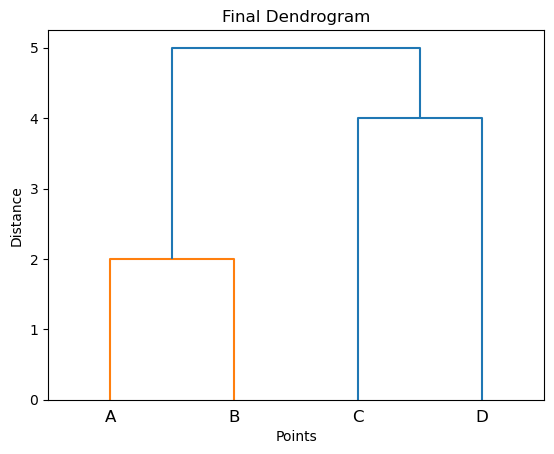

In [13]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
import numpy as np

labels = ['A','B','C','D']

# Convert to float (VERY IMPORTANT)
Z = np.array([
    [0, 1, 2, 2],
    [2, 3, 4, 2],
    [4, 5, 5, 4]
], dtype=float)

plt.figure()
dendrogram(Z, labels=labels)
plt.title("Final Dendrogram")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

Linkage Matrix:
 [[0. 1. 3. 2.]
 [2. 3. 4. 2.]
 [4. 5. 5. 4.]]


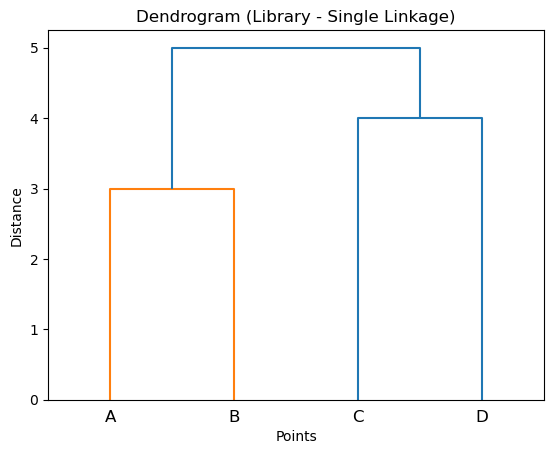

In [14]:
#using library
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Condensed distance matrix
# Order: AB, AC, AD, BC, BD, CD
dist = [3,6,8,5,7,4]

Z = linkage(dist, method='single')

print("Linkage Matrix:\n", Z)

plt.figure()
dendrogram(Z, labels=['A','B','C','D'])
plt.title("Dendrogram (Library - Single Linkage)")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

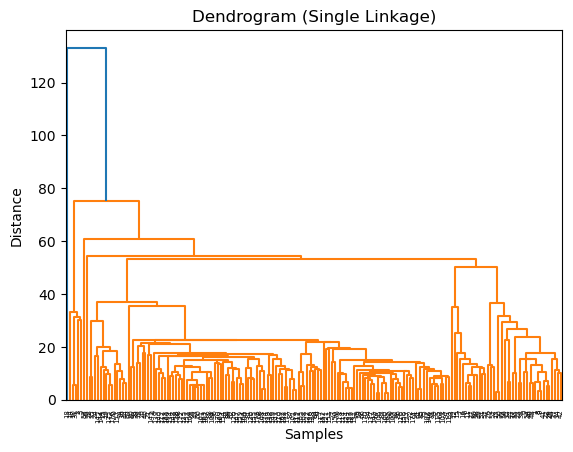

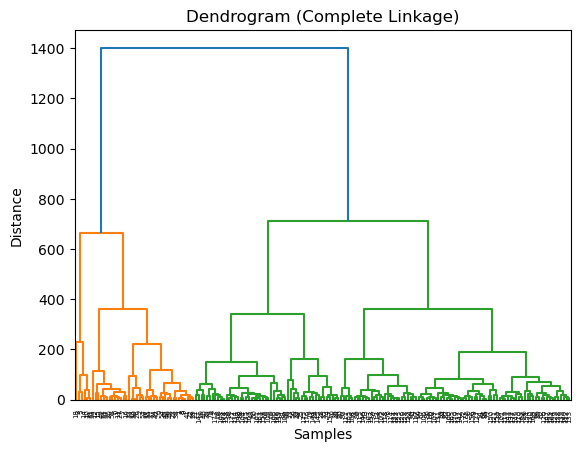

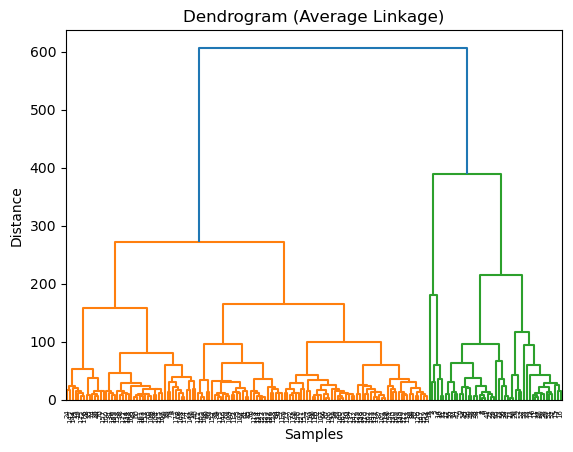

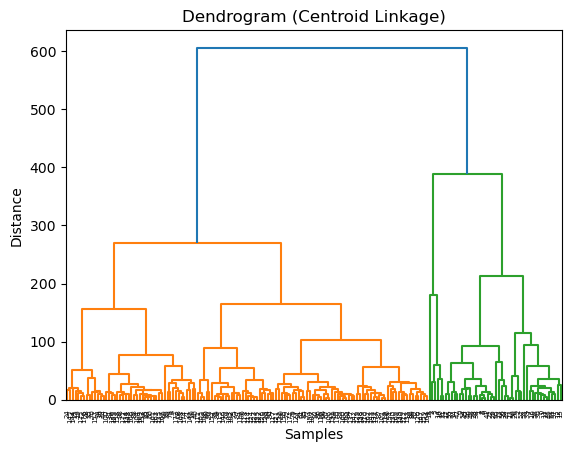


Linkage: single
Cluster Labels: [0 0 0 2 0 2 0 0 0 0 2 0 0 0 2 0 0 0 1 0]

Linkage: complete
Cluster Labels: [0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2]

Linkage: average
Cluster Labels: [1 1 1 2 0 2 1 1 1 1 2 1 1 1 2 1 1 1 2 0]
Divisive step 1 (2 clusters): [1 1 1 1 0 1 1 1 1 1 1 1 1 1 1]
Divisive step 2 (sub-clustering)


c:\Users\22anj\anaconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\22anj\anaconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [18]:
# Q.6 Using Wine Dataset : Apply hierarchical clustering, Plot dendrogram, Compare linkage methods

from sklearn.datasets import load_wine
import numpy as np

data = load_wine()
X = data.data

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

methods = ['single', 'complete', 'average', 'centroid']

for method in methods:
    plt.figure()
    
    Z = linkage(X, method=method)
    
    dendrogram(Z)
    
    plt.title(f"Dendrogram ({method.capitalize()} Linkage)")
    plt.xlabel("Samples")
    plt.ylabel("Distance")
    plt.show()

# Agglomerative
from sklearn.cluster import AgglomerativeClustering

for method in ['single', 'complete', 'average']:
    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(X)
    
    print(f"\nLinkage: {method}")
    print("Cluster Labels:", labels[:20])  # first 20

#Divisive has no such library so we can use kmeans for splitting and clustering 
from sklearn.cluster import KMeans

# Start with all data → split into 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(X)

print("Divisive step 1 (2 clusters):", labels[:15])

# Further split one cluster (example)
cluster1 = X[labels == 0]

kmeans2 = KMeans(n_clusters=2, random_state=0)
sub_labels = kmeans2.fit_predict(cluster1)

print("Divisive step 2 (sub-clustering)")



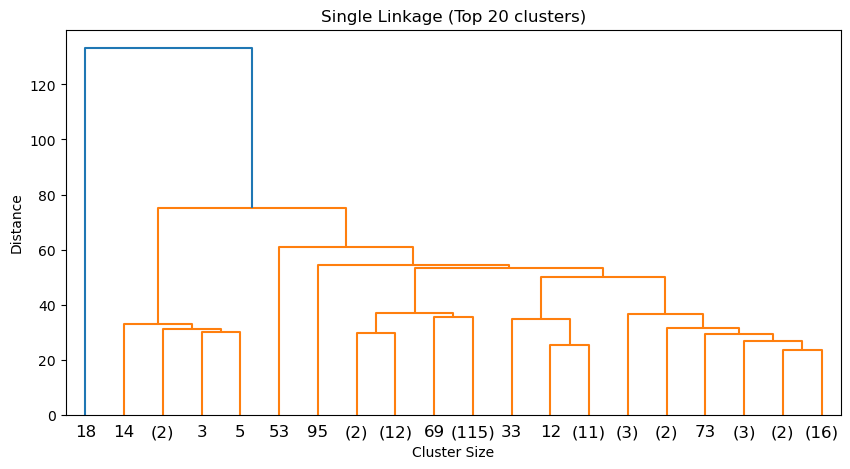

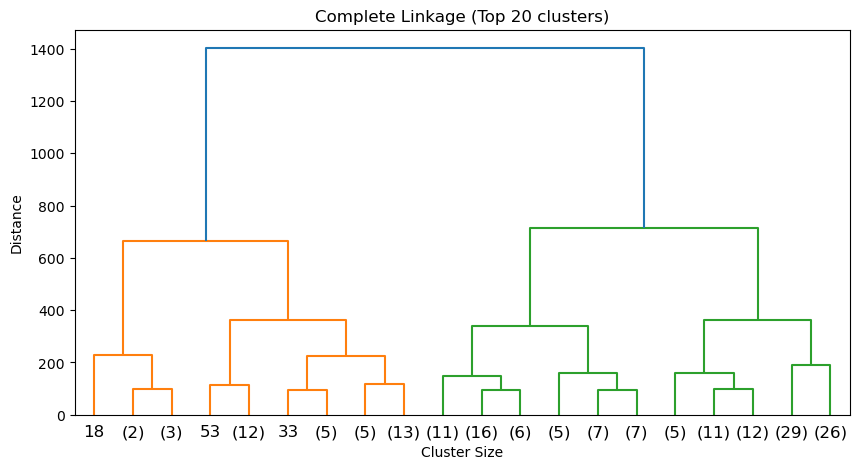

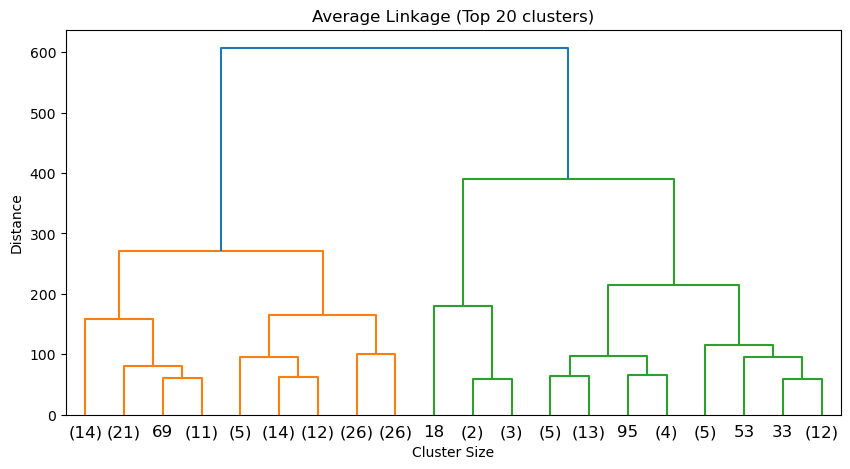

In [19]:
# dendrogram understand
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

methods = ['single', 'complete', 'average']

for method in methods:
    plt.figure(figsize=(10,5))
    
    Z = linkage(X, method=method)
    
    dendrogram(Z, truncate_mode='lastp', p=20)
    
    plt.title(f"{method.capitalize()} Linkage (Top 20 clusters)")
    plt.xlabel("Cluster Size")
    plt.ylabel("Distance")
    plt.show()

In [20]:
#Silhouette score for linkages
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

methods = ['single', 'complete', 'average']

for method in methods:
    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(X)
    
    score = silhouette_score(X, labels)
    
    print(f"Linkage: {method}")
    print(f"Silhouette Score: {score:.4f}\n")

Linkage: single
Silhouette Score: 0.4880

Linkage: complete
Silhouette Score: 0.5419

Linkage: average
Silhouette Score: 0.6101



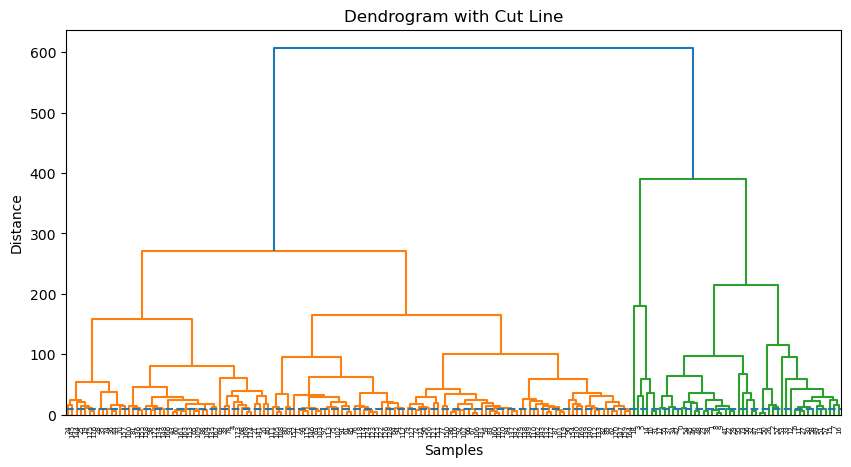

Cluster labels: [3 3 3 2 1 2 3 3 3 3 2 3 3 3 2 3 3 3 2 1]


In [21]:
#visual Cut
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='average')

plt.figure(figsize=(10,5))
dendrogram(Z)

# Draw horizontal cut line
plt.axhline(y=10, linestyle='--')  # change value

plt.title("Dendrogram with Cut Line")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

from scipy.cluster.hierarchy import fcluster

clusters = fcluster(Z, t=3, criterion='maxclust')
print("Cluster labels:", clusters[:20])

clusters = fcluster(Z, t=10, criterion='distance')

In [22]:
# Q.7 Perform PCA with scratch over the datapoints: (2,4), (3,6), (4,8), (5,10) 
#Perform : Standardization, Covariance matrix calculation, Eigenvalues & eigenvectors, 
#Project data onto principal component 

import numpy as np

X = np.array([[2,4],[3,6],[4,8],[5,10]])

# Step 1: Mean
mean = np.mean(X, axis=0)

# Step 2: Centering
X_centered = X - mean

# Step 3: Covariance matrix
cov_matrix = np.cov(X_centered.T)

# Step 4: Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Step 5: Sort eigenvalues
idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]

# Step 6: Projection
PC1 = eigenvectors[:,0]
Z = X_centered @ PC1

print("Mean:", mean)
print("Covariance Matrix:\n", cov_matrix)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)
print("Projection:\n", Z)

Mean: [3.5 7. ]
Covariance Matrix:
 [[1.66666667 3.33333333]
 [3.33333333 6.66666667]]
Eigenvalues: [0.         8.33333333]
Eigenvectors:
 [[-0.4472136  -0.89442719]
 [-0.89442719  0.4472136 ]]
Projection:
 [ 3.35410197  1.11803399 -1.11803399 -3.35410197]


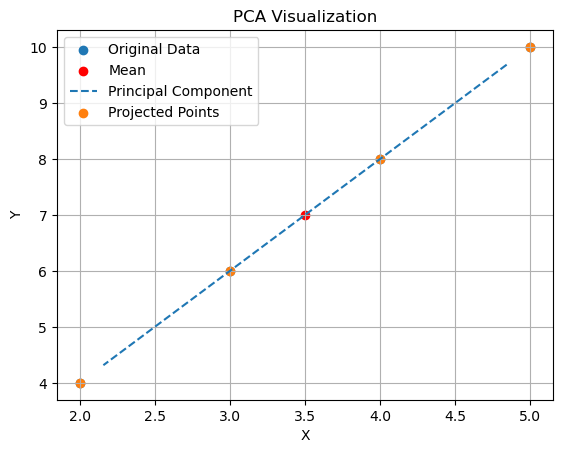

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Original data
X = np.array([[2,4],[3,6],[4,8],[5,10]])

# Step 1: Mean
mean = np.mean(X, axis=0)

# Step 2: Center data
X_centered = X - mean

# Step 3: Covariance matrix
cov = np.cov(X_centered.T)

# Step 4: Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov)

# Step 5: Select principal component
idx = np.argmax(eigenvalues)
PC1 = eigenvectors[:, idx]

# Step 6: Projection
Z = X_centered @ PC1
X_proj = np.outer(Z, PC1) + mean

# ---------------- VISUALIZATION ----------------

plt.figure()

# Original points
plt.scatter(X[:,0], X[:,1], label="Original Data")

# Mean point
plt.scatter(mean[0], mean[1], color='red', label="Mean")

# Principal Component line
line = np.array([mean - 3*PC1, mean + 3*PC1])
plt.plot(line[:,0], line[:,1], linestyle='--', label="Principal Component")

# Projected points
plt.scatter(X_proj[:,0], X_proj[:,1], label="Projected Points")

# Draw projection lines
for i in range(len(X)):
    plt.plot([X[i,0], X_proj[i,0]], [X[i,1], X_proj[i,1]], linestyle='dotted')

plt.title("PCA Visualization")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid()
plt.show()

Principal Component:
 [[0.4472136  0.89442719]]
Explained Variance: [8.33333333]
Projected Data:
 [[-3.35410197]
 [-1.11803399]
 [ 1.11803399]
 [ 3.35410197]]


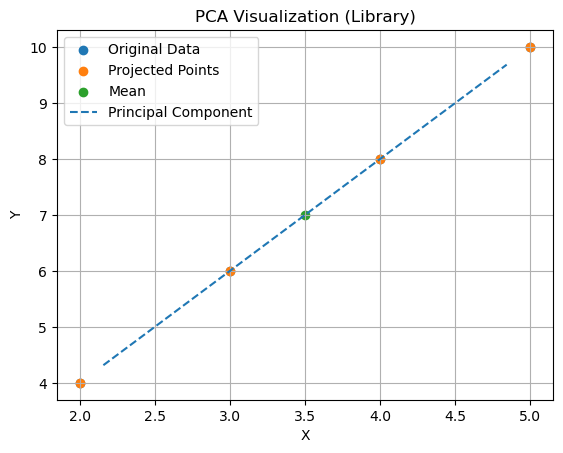

In [27]:
from sklearn.decomposition import PCA
import numpy as np

X = np.array([[2,4],[3,6],[4,8],[5,10]])

pca = PCA(n_components=1)
Z = pca.fit_transform(X)

print("Principal Component:\n", pca.components_)
print("Explained Variance:", pca.explained_variance_)
print("Projected Data:\n", Z)

# Reconstruct projected points
X_proj = pca.inverse_transform(Z)

# Mean
mean = pca.mean_

# Principal component direction
pc = pca.components_[0]

# ---------------- Visualization ----------------

plt.figure()

# Original points
plt.scatter(X[:,0], X[:,1], label="Original Data")

# Projected points
plt.scatter(X_proj[:,0], X_proj[:,1], label="Projected Points")

# Mean point
plt.scatter(mean[0], mean[1], label="Mean")

# Principal component line
line = np.array([mean - 3*pc, mean + 3*pc])
plt.plot(line[:,0], line[:,1], linestyle='--', label="Principal Component")

# Projection lines
for i in range(len(X)):
    plt.plot([X[i,0], X_proj[i,0]], [X[i,1], X_proj[i,1]], linestyle='dotted')

plt.title("PCA Visualization (Library)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid()
plt.show()


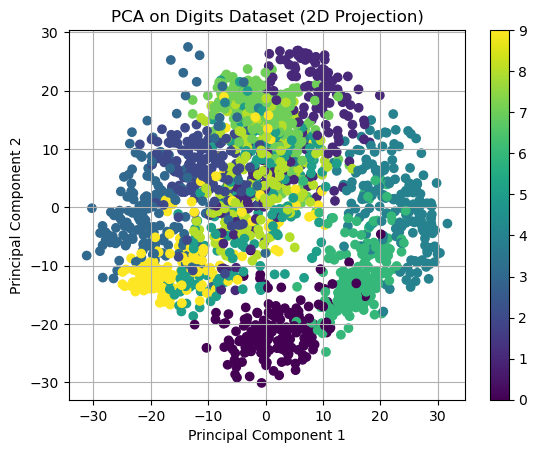

In [ ]:
# Q.8 Using Digits dataset: Apply PCA, Reduce dimensions to 2D, Plot transformed data , 64D to 2D

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load dataset
digits = load_digits()
X = digits.data
y = digits.target

# Apply PCA (reduce to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot
plt.figure()

scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Digits Dataset (2D Projection)")

plt.colorbar(scatter)
plt.grid()

plt.show()

In [29]:
#Q.9 Anomaly Detection: performing over your random data , compute mean and standard deviation, calculate Z-Score, identify anomalies for |Z|>2.

# using generating sample data
import numpy as np

np.random.seed(0)

# Normal data
data = np.random.normal(loc=50, scale=5, size=20)

# Add anomalies
data = np.append(data, [90, 100])

print("Data:\n", data)

mean = np.mean(data)
print("Mean:", mean)

std = np.std(data)
print("Standard Deviation:", std)

z_scores = (data - mean) / std

print("Z-Scores:\n", z_scores)

threshold = 2

anomalies = data[np.abs(z_scores) > threshold]

print("Anomalies:", anomalies)

Data:
 [ 58.82026173  52.00078604  54.89368992  61.204466    59.33778995
  45.1136106   54.75044209  49.24321396  49.48390574  52.05299251
  50.72021786  57.27136753  53.80518863  50.60837508  52.21931616
  51.66837164  57.47039537  48.97420868  51.56533851  45.7295213
  90.         100.        ]
Mean: 56.67879360429834
Standard Deviation: 12.866690766570061
Z-Scores:
 [ 0.16643503 -0.36357504 -0.13873837  0.35173554  0.20665736 -0.89884674
 -0.1498716  -0.57789371 -0.55918713 -0.35951755 -0.46310087  0.04605488
 -0.22333676 -0.4717933  -0.34659086 -0.3894103   0.06152334 -0.59880082
 -0.39741805 -0.85097812  2.58972622  3.36692683]
Anomalies: [ 90. 100.]


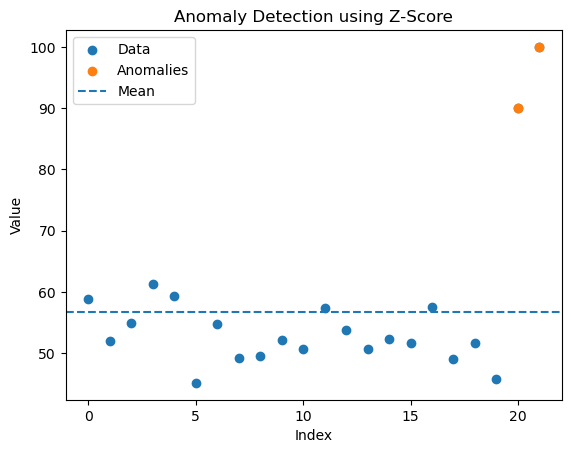

In [30]:
#visualization
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(range(len(data)), data, label="Data")

# Highlight anomalies
plt.scatter(np.where(np.abs(z_scores) > 2),
            anomalies,
            label="Anomalies")

plt.axhline(mean, linestyle='--', label="Mean")

plt.title("Anomaly Detection using Z-Score")
plt.xlabel("Index")
plt.ylabel("Value")

plt.legend()
plt.show()

Q1: 50.6363357757992
Q3: 57.42063840804474
IQR: 6.784302632245534
Lower Bound: 40.459881827430905
Upper Bound: 67.59709235641304
Anomalies: [ 90. 100.]


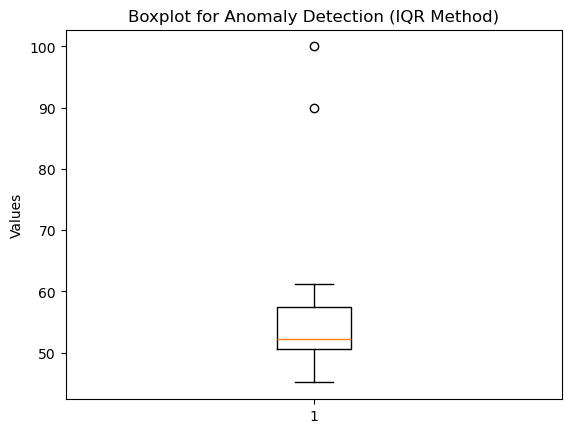

In [31]:
#using boxplot method over same data generated

Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

anomalies = data[(data < lower_bound) | (data > upper_bound)]

print("Anomalies:", anomalies)

import matplotlib.pyplot as plt

plt.figure()

plt.boxplot(data)

plt.title("Boxplot for Anomaly Detection (IQR Method)")
plt.ylabel("Values")

plt.show()

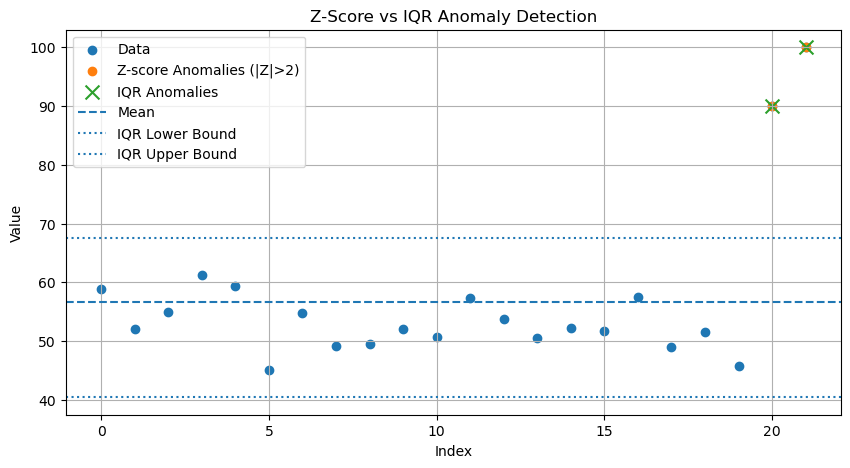

In [33]:
#common plot to compare zscore and boxplot
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Data ----------------
np.random.seed(0)
data = np.random.normal(loc=50, scale=5, size=20)
data = np.append(data, [90, 100])  # anomalies

# ---------------- Z-SCORE ----------------
mean = np.mean(data)
std = np.std(data)

z_scores = (data - mean) / std
z_anomalies = np.abs(z_scores) > 2

# ---------------- IQR ----------------
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_anomalies = (data < lower_bound) | (data > upper_bound)

plt.figure(figsize=(10,5))

# All data
plt.scatter(range(len(data)), data, label="Data")

# Z-score anomalies
plt.scatter(np.where(z_anomalies), data[z_anomalies],
            label="Z-score Anomalies (|Z|>2)")

# IQR anomalies
plt.scatter(np.where(iqr_anomalies), data[iqr_anomalies],
            marker='x', s=100,
            label="IQR Anomalies")

# Mean line
plt.axhline(mean, linestyle='--', label="Mean")

# IQR bounds
plt.axhline(lower_bound, linestyle=':', label="IQR Lower Bound")
plt.axhline(upper_bound, linestyle=':', label="IQR Upper Bound")

plt.title("Z-Score vs IQR Anomaly Detection")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid()

plt.show()

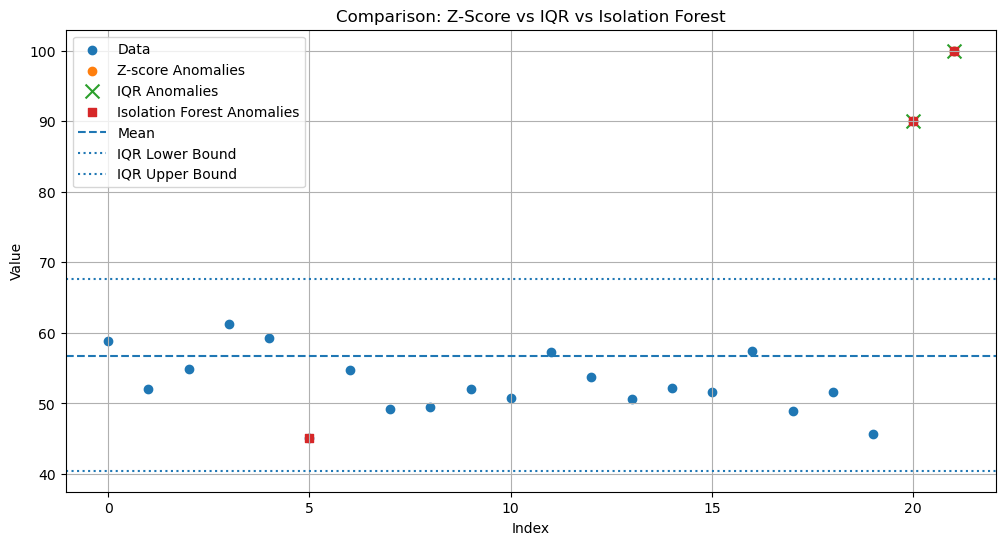

In [34]:
# Zscore+boxplot+isolation forest

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# ---------------- Data ----------------
np.random.seed(0)
data = np.random.normal(loc=50, scale=5, size=20)
data = np.append(data, [90, 100])  # anomalies
data = data.reshape(-1, 1)

# ---------------- Z-SCORE ----------------
mean = np.mean(data)
std = np.std(data)

z_scores = (data - mean) / std
z_anomalies = np.abs(z_scores) > 2

# ---------------- IQR ----------------
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_anomalies = (data < lower_bound) | (data > upper_bound)

# ---------------- ISOLATION FOREST ----------------
iso = IsolationForest(contamination=0.1, random_state=0)
preds = iso.fit_predict(data)

# -1 → anomaly, 1 → normal
iso_anomalies = preds == -1

# ---------------- PLOT ----------------
plt.figure(figsize=(12,6))

x = np.arange(len(data))

# All data
plt.scatter(x, data, label="Data")

# Z-score anomalies
plt.scatter(x[z_anomalies.flatten()], data[z_anomalies],
            label="Z-score Anomalies")

# IQR anomalies
plt.scatter(x[iqr_anomalies.flatten()], data[iqr_anomalies],
            marker='x', s=100,
            label="IQR Anomalies")

# Isolation Forest anomalies
plt.scatter(x[iso_anomalies], data[iso_anomalies],
            marker='s',
            label="Isolation Forest Anomalies")

# Mean line
plt.axhline(mean, linestyle='--', label="Mean")

# IQR bounds
plt.axhline(lower_bound, linestyle=':', label="IQR Lower Bound")
plt.axhline(upper_bound, linestyle=':', label="IQR Upper Bound")

plt.title("Comparison: Z-Score vs IQR vs Isolation Forest")
plt.xlabel("Index")
plt.ylabel("Value")

plt.legend()
plt.grid()
plt.show()

In [35]:
#Q10.  Perform Anomaly Detection over Breast Cancer Dataset.

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target   # 0 = malignant, 1 = benign

from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=0)

preds = iso.fit_predict(X)

# Convert: -1 → anomaly, 1 → normal
import numpy as np
anomalies = np.where(preds == -1)[0]

print("Number of anomalies detected:", len(anomalies))

Number of anomalies detected: 29


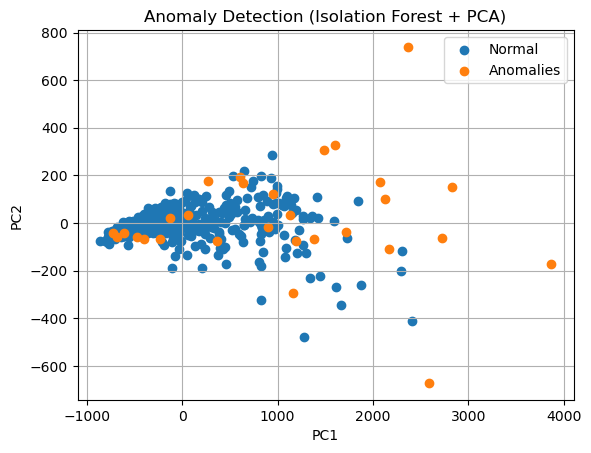

In [36]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()

# Normal points
plt.scatter(X_pca[preds==1, 0], X_pca[preds==1, 1],
            label="Normal")

# Anomalies
plt.scatter(X_pca[preds==-1, 0], X_pca[preds==-1, 1],
            label="Anomalies")

plt.title("Anomaly Detection (Isolation Forest + PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()

plt.show()

In [37]:
# Malignant = 0 (can be considered abnormal)
actual_anomalies = (y == 0)

print("Actual malignant cases:", sum(actual_anomalies))
print("Detected anomalies:", sum(preds == -1))

overlap = np.sum((preds == -1) & (y == 0))
print("Correctly identified malignant as anomalies:", overlap)

Actual malignant cases: 212
Detected anomalies: 29
Correctly identified malignant as anomalies: 26


In [38]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

preds = lof.fit_predict(X)

# -1 = anomaly, 1 = normal
anomalies = np.where(preds == -1)[0]

print("Number of anomalies detected:", len(anomalies))

Number of anomalies detected: 29


In [39]:
scores = lof.negative_outlier_factor_

print("LOF Scores (first 10):", scores[:10])

LOF Scores (first 10): [-1.42244008 -1.06678249 -0.97894764 -1.59693295 -1.06993589 -1.773071
 -1.01568723 -1.25174625 -1.38051485 -1.64435685]


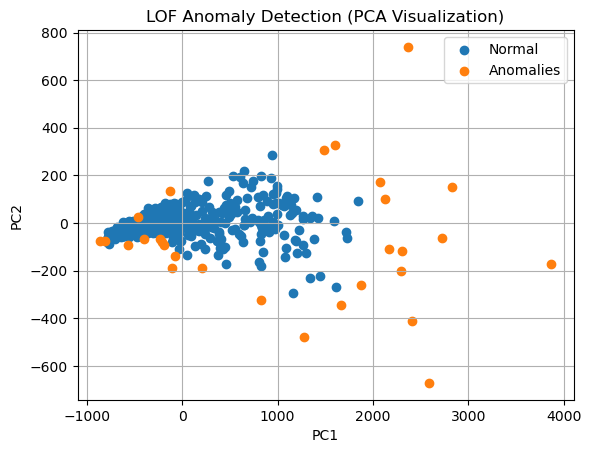

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()

# Normal
plt.scatter(X_pca[preds==1, 0], X_pca[preds==1, 1],
            label="Normal")

# Anomalies
plt.scatter(X_pca[preds==-1, 0], X_pca[preds==-1, 1],
            label="Anomalies")

plt.title("LOF Anomaly Detection (PCA Visualization)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()

plt.show()